In [1]:
import pandas as pd

In [2]:
df= pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
# Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score



X = df.drop(["Outcome"], axis=1)
y = df["Outcome"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:

model = LogisticRegression(C=0.5, max_iter=2000)  # smaller C = stronger regularization
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

In [8]:
# Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Cross Validation
scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print("\nCross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Accuracy: 0.7403

Confusion Matrix:
[[78 21]
 [19 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154


Cross-validation scores: [0.76623377 0.74675325 0.75974026 0.81045752 0.77777778]
Mean accuracy: 0.772192513368984


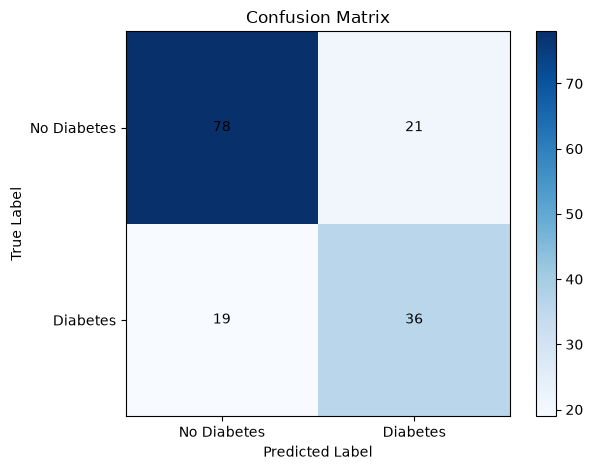

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Define your class labels (change according to your problem)
labels = ["No Diabetes", "Diabetes"]   # e.g. ["Cat", "Dog"]

plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add ticks and labels
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
# Take predictions for first 1 sample
data=[[0, 100, 80, 35, 0, 25.6, 0.201, 30]]
prediction = model.predict(data)
print("Prediction for data ",prediction)


Prediction for data  [0]


c:\Users\hp\OneDrive\Desktop\Logistic\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [12]:
# Saving model Pkl File
import pickle
with open("logistic_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)